## Salary Classification Using Decision Tree 

In [156]:
#importing the dependencies
import pandas as pd
from sklearn import tree
from sklearn.model_selection import train_test_split,cross_val_score,LeaveOneOut
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,f1_score,recall_score

In [157]:
#loading the dataset
df=pd.read_csv("salaries.csv")

- Exploring the data

In [158]:
df.shape

(16, 4)

In [159]:
df.head()

,company,job,degree,salary_more_then_100k
0,google,sales executive,bachelors,0
1,google,sales executive,masters,0
2,google,business manager,bachelors,1
3,google,business manager,masters,1
4,google,computer programmer,bachelors,0


In [160]:
df['salary_more_then_100k'].value_counts()

salary_more_then_100k
1    10
0     6
Name: count, dtype: int64

0 - does not get a salary more than 100k

1 - get salary more than 100k

- Splitting features and target

In [161]:
x=df.drop(columns=['salary_more_then_100k'])
y=df['salary_more_then_100k']

- Label encoding

In [162]:
le=LabelEncoder()
for col in x.columns:
    x[col]=le.fit_transform(x[col])
print(" Encoded Features: \n",x)

 Encoded Features: 
     company  job  degree
0         2    2       0
1         2    2       1
2         2    0       0
3         2    0       1
4         2    1       0
5         2    1       1
6         0    2       1
7         0    1       0
8         0    0       0
9         0    0       1
10        1    2       0
11        1    2       1
12        1    0       0
13        1    0       1
14        1    1       0
15        1    1       1


In [163]:
y

0     0
1     0
2     1
3     1
4     0
5     1
6     0
7     0
8     0
9     1
10    1
11    1
12    1
13    1
14    1
15    1
Name: salary_more_then_100k, dtype: int64

- Splitting the training and testing data

In [164]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

- Training the model

In [165]:
model=tree.DecisionTreeClassifier(max_depth=2, random_state=42)

In [166]:
model.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [167]:
y_test_pred=model.predict(x_test)
print("Predictions:",y_test_pred)
print("Actual: ",list(y_test))

Predictions: [1 1 1 1]
Actual:  [0, 0, 1, 1]


- Model evaluation

In [168]:
#accuracy score
accuracy=accuracy_score(y_test,y_test_pred)
precision=precision_score(y_test,y_test_pred)
recall=recall_score(y_test,y_test_pred)
f1=f1_score(y_test,y_test_pred)
print("Accuracy score: ",accuracy)
print("Precision score: ",precision)
print("Recall score: ",recall)
print("F1 score: ",f1)


Accuracy score:  0.5
Precision score:  0.5
Recall score:  1.0
F1 score:  0.6666666666666666


- Cross Validation

In [169]:
#cross value
loo=LeaveOneOut()
cv_model=tree.DecisionTreeClassifier(max_depth=2,random_state=42)
cv_scores=cross_val_score(model,x,y,cv=loo)
print("Cross value scores for each folds: ",cv_scores)
print("Cross value accuracy: ",cv_scores.mean())

Cross value scores for each folds:  [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 1. 1. 1.]
Cross value accuracy:  0.3125


- Confusion Matrix

In [170]:
cm=confusion_matrix(y_test,y_test_pred)
print(cm)

[[0 2]
 [0 2]]


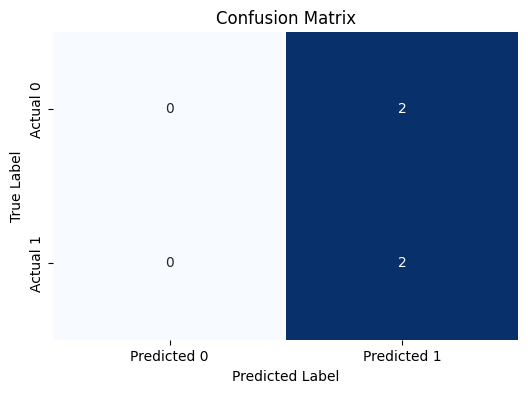

In [171]:
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',cbar=False,
            xticklabels=['Predicted 0','Predicted 1'],
            yticklabels=['Actual 0','Actual 1'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.savefig("Confusion_matrix.png",dpi=300,bbox_inches='tight')
plt.show()

- Decision Tree Visualisation

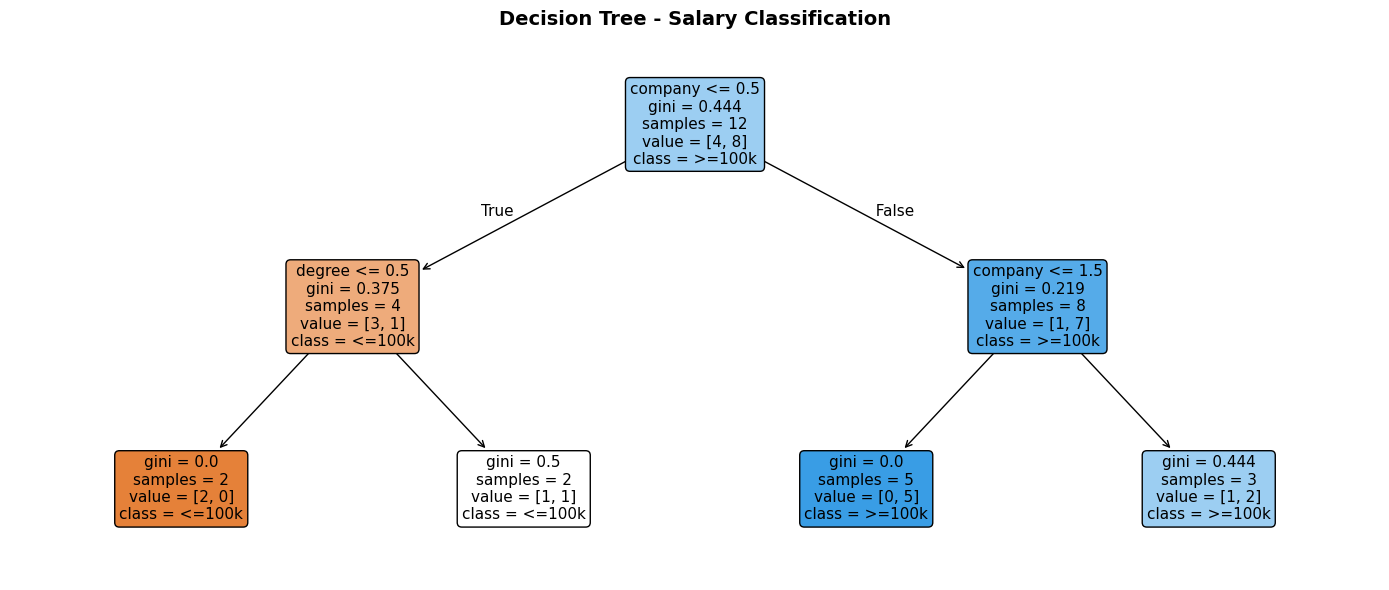

In [173]:
plt.figure(figsize=(14,6))
tree.plot_tree(model,feature_names=['company','job','degree'],
               class_names=['<=100k','>=100k'],
               filled=True,
               rounded=True,
               fontsize=11)
plt.title("Decision Tree - Salary Classification",
          fontsize=14,fontweight='bold')
plt.tight_layout()
plt.savefig("Decision_tree_visualization",dpi=300,bbox_inches='tight')
plt.show()